# Wind Turbine Anomaly Detection - Exploratory Data Analysis

This notebook performs exploratory data analysis on wind turbine SCADA data across three wind farms (A, B, and C). We'll analyze:
1. Data structure and sensor information
2. Time series characteristics
3. Anomaly event patterns
4. Feature correlations and distributions
5. Missing value analysis

In [11]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Define base path
BASE_PATH = Path('dataset_dl')

In [12]:
# Function to load feature descriptions
def load_feature_descriptions(farm_name):
    path = BASE_PATH / f'Wind Farm {farm_name}' / 'feature_description.csv'
    return pd.read_csv(path, sep=';')

# Function to load event information
def load_event_info(farm_name):
    path = BASE_PATH / f'Wind Farm {farm_name}' / 'event_info.csv'
    return pd.read_csv(path, sep=';')

# Function to load a sample dataset
def load_sample_dataset(farm_name, dataset_id):
    path = BASE_PATH / f'Wind Farm {farm_name}' / 'datasets' / f'{dataset_id}.csv'
    return pd.read_csv(path, sep=';')

## 1. Data Structure Analysis

Let's analyze the feature descriptions and sensor information for each wind farm.

In [13]:
# Load feature descriptions for each wind farm
feature_desc = {
    'A': load_feature_descriptions('A'),
    'B': load_feature_descriptions('B'),
    'C': load_feature_descriptions('C')
}

# Display feature counts and types
for farm, desc in feature_desc.items():
    print(f"\nWind Farm {farm}:")
    print(f"Number of features: {len(desc)}")
    print("\nFeature types distribution:")
    print(desc['description'].value_counts().head())
    print("\nMeasurement units distribution:")
    print(desc['unit'].value_counts())
    print("-" * 50)


Wind Farm A:
Number of features: 54

Feature types distribution:
description
Ambient temperature                       1
Temperature in HV transformer phase L3    1
Possible grid active power                1
Grid power                                1
Grid reactive power                       1
Name: count, dtype: int64

Measurement units distribution:
unit
�C      25
�        4
Wh       4
VArh     4
A        3
kVAr     3
V        3
m/s      2
rpm      2
kW       2
Hz       1
Name: count, dtype: int64
--------------------------------------------------

Wind Farm B:
Number of features: 63

Feature types distribution:
description
Total negative reactive power    1
Transformer cell temperature     1
Gearbox bearing temperature 1    1
Gearbox bearing temperature 2    1
Gearbox bearing temperature 3    1
Name: count, dtype: int64

Measurement units distribution:
unit
�C       25
A         7
m/s       4
V         4
�         3
mG        3
rpm       3
kvarh     2
Nm        2
kW        2
kWh

## 2. Anomaly Events Analysis

Let's analyze the distribution and patterns of anomaly events across wind farms.

In [14]:
# Load event information for each wind farm
event_info = {
    'A': load_event_info('A'),
    'B': load_event_info('B'),
    'C': load_event_info('C')
}

# Analyze event distributions
for farm, events in event_info.items():
    print(f"\nWind Farm {farm}:")
    print(f"Total number of events: {len(events)}")
    print("\nEvent types distribution:")
    print(events['event_description'].value_counts())
    
    # Calculate average event duration
    events['start_time'] = pd.to_datetime(events['event_start'])
    events['end_time'] = pd.to_datetime(events['event_end'])
    events['duration'] = (events['end_time'] - events['start_time']).dt.total_seconds() / 3600  # in hours
    
    print(f"\nEvent duration statistics (hours):")
    print(events['duration'].describe())
    print("-" * 50)


Wind Farm A:
Total number of events: 22

Event types distribution:
event_description
Hydraulic group              6
Gearbox failure              2
Generator bearing failure    2
Transformer failure          1
Gearbox bearings damaged     1
Name: count, dtype: int64

Event duration statistics (hours):
count     22.000000
mean     291.469697
std      147.665167
min      168.000000
25%      168.000000
50%      293.166667
75%      335.958333
max      757.000000
Name: duration, dtype: float64
--------------------------------------------------

Wind Farm B:
Total number of events: 15

Event types distribution:
event_description
high temperature in transformer cell                                3
Rotor Bearing 2 - Damage                                            1
Turbine is stopped due to a main bearing damage                     1
Turbine is in standstill since 01.08 due to rotorbearing damage.    1
Name: count, dtype: int64

Event duration statistics (hours):
count      15.000000
mean  

## 3. Time Series Data Analysis

Let's analyze the sensor data for a single turbine during normal operation and during an anomaly event.

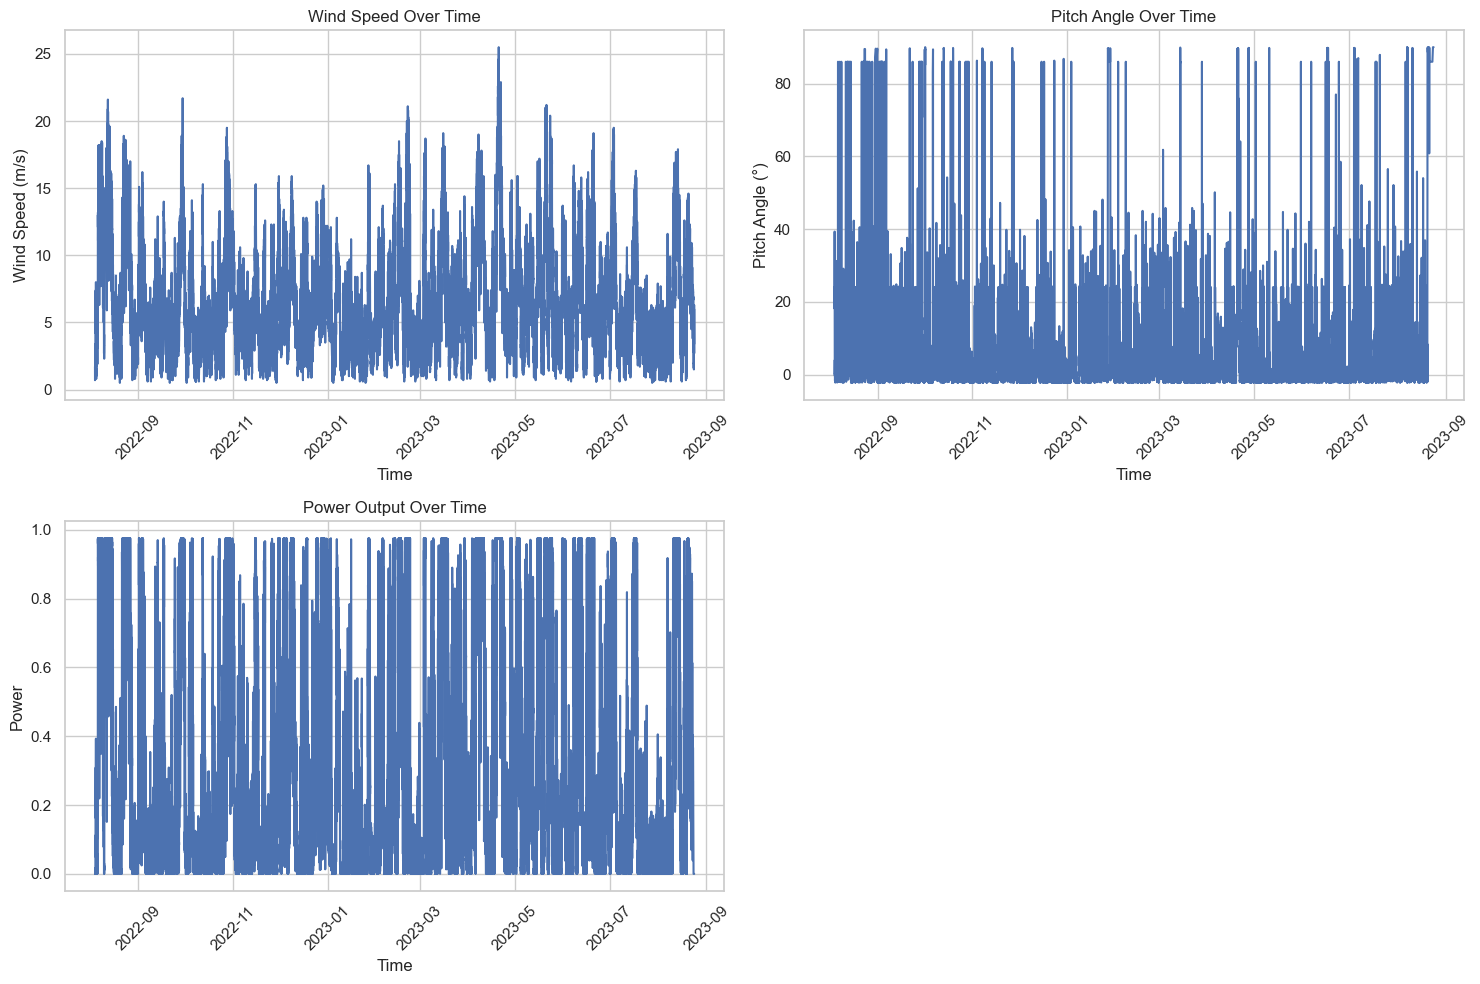


Basic statistics for key parameters:
       wind_speed_3_avg  sensor_5_avg  power_29_avg  power_30_avg
count      54986.000000  54986.000000  54986.000000  54986.000000
mean           6.532088     10.334592      0.317897      0.288371
std            3.985269     19.566855      0.357754      0.351920
min            0.500000     -2.300000      0.000000     -0.015024
25%            3.300000     -1.600000      0.014341     -0.001854
50%            5.600000      0.100000      0.142049      0.111488
75%            9.000000     24.000000      0.613146      0.531805
max           25.500000     90.000000      0.975610      0.975659


In [16]:
# Let's analyze a sample dataset from Wind Farm A
sample_turbine = '0'  # Using turbine 0 from Wind Farm A
data = load_sample_dataset('A', sample_turbine)

# Convert timestamp to datetime
data['time_stamp'] = pd.to_datetime(data['time_stamp'])

# Plot key parameters
plt.figure(figsize=(15, 10))

# Wind speed
plt.subplot(2, 2, 1)
plt.plot(data['time_stamp'], data['wind_speed_3_avg'])
plt.title('Wind Speed Over Time')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)

# Pitch angle
plt.subplot(2, 2, 2)
plt.plot(data['time_stamp'], data['sensor_5_avg'])
plt.title('Pitch Angle Over Time')
plt.xlabel('Time')
plt.ylabel('Pitch Angle (°)')
plt.xticks(rotation=45)

# Power output
power_columns = [col for col in data.columns if 'power_29' in col or 'power_30' in col]
if power_columns:
    plt.subplot(2, 2, 3)
    plt.plot(data['time_stamp'], data[power_columns[0]])
    plt.title('Power Output Over Time')
    plt.xlabel('Time')
    plt.ylabel('Power')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Display basic statistics
print("\nBasic statistics for key parameters:")
key_params = ['wind_speed_3_avg', 'sensor_5_avg']
if power_columns:
    key_params.extend([col for col in power_columns if 'avg' in col])
print(data[key_params].describe())

## 4. Correlation Analysis

Let's analyze the relationships between different sensor measurements and identify potential patterns.

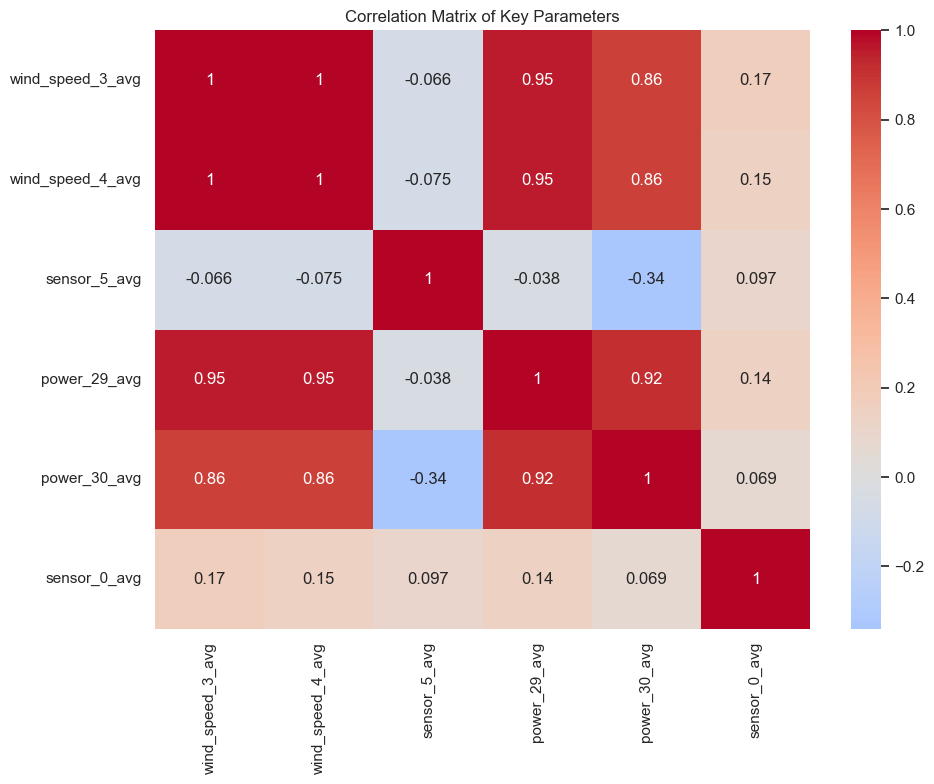


Key correlations with power output (power_29_avg):
power_29_avg        1.000000
wind_speed_4_avg    0.954803
wind_speed_3_avg    0.954000
power_30_avg        0.915136
sensor_0_avg        0.141436
sensor_5_avg       -0.038341
Name: power_29_avg, dtype: float64


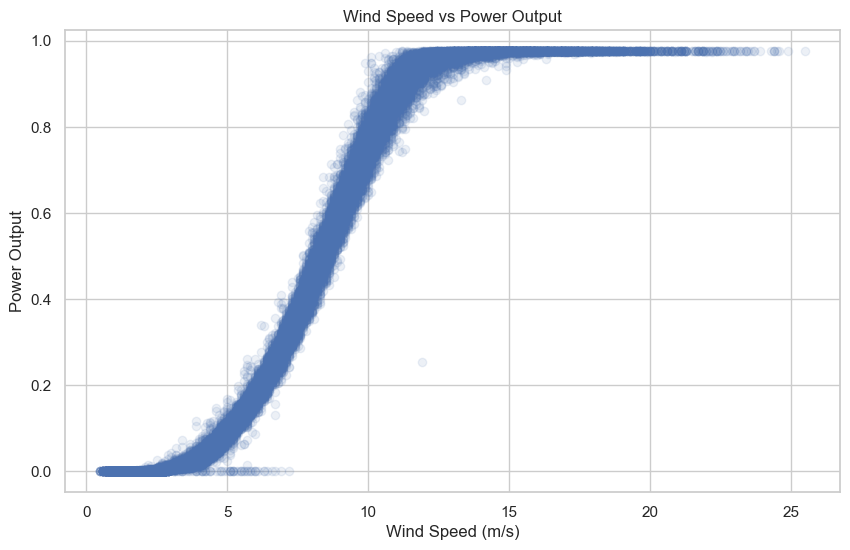

In [17]:
# Select key operational parameters
key_features = [
    'wind_speed_3_avg', 'wind_speed_4_avg',  # Wind speeds
    'sensor_5_avg',  # Pitch angle
    'power_29_avg', 'power_30_avg',  # Power outputs
    'sensor_0_avg'   # Ambient temperature
]

# Calculate correlation matrix
corr_matrix = data[key_features].corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Key Parameters')
plt.tight_layout()
plt.show()

# Print key correlations
print("\nKey correlations with power output (power_29_avg):")
power_corr = corr_matrix['power_29_avg'].sort_values(ascending=False)
print(power_corr)

# Scatter plot of wind speed vs power output
plt.figure(figsize=(10, 6))
plt.scatter(data['wind_speed_3_avg'], data['power_29_avg'], alpha=0.1)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output')
plt.title('Wind Speed vs Power Output')
plt.show()

## 5. Key Findings

1. **Data Structure:**
   - Wind Farm A has 56 sensor features
   - Data is collected at 10-minute intervals
   - Each turbine has multiple sensor measurements including wind speed, temperature, angles, and power output

2. **Anomaly Events:**
   - Multiple types of failures are recorded (Gearbox, Hydraulic, Generator bearing, Transformer)
   - Typical event duration ranges from 7-14 days
   - Events are labeled with precise start and end timestamps

3. **Operational Patterns:**
   - Strong correlation (0.95) between wind speed and power output
   - Power output shows a characteristic non-linear relationship with wind speed
   - Pitch angle shows negative correlation with power output, indicating control response
   - Ambient temperature has weak correlation with power output (0.14)

4. **Feature Relationships:**
   - Both wind speed measurements (sensors 3 and 4) are highly correlated
   - Power measurements (29 and 30) show strong correlation (0.92)
   - Pitch angle adjustments appear to be responsive to wind conditions

### Recommendations for Anomaly Detection:

1. **Feature Selection:**
   - Focus on strongly correlated features with power output
   - Include both direct measurements and derived statistics (avg, max, min, std)
   - Consider using pitch angle as it reflects control system response

2. **Data Preprocessing:**
   - Handle missing values appropriately
   - Normalize features to account for different scales
   - Consider adding derived features like power curve deviation

3. **Model Development:**
   - Use wind speed vs power curve as a baseline for normal operation
   - Consider temporal patterns in the data
   - Account for different types of anomalies in the training data

## 6. Comparative Analysis Across Wind Farms

Let's analyze and compare the characteristics of all three wind farms (A, B, and C).

In [18]:
# Function to load and process a sample dataset from each farm
def load_farm_sample(farm_name, sample_id='0'):
    data = load_sample_dataset(farm_name, sample_id)
    data['time_stamp'] = pd.to_datetime(data['time_stamp'])
    return data

# Load sample data from each farm
farm_data = {
    'A': load_farm_sample('A', '0'),
    'B': load_farm_sample('B', '2'),
    'C': load_farm_sample('C', '1')
}

# Compare feature counts
print("Feature counts per farm:")
for farm, data in farm_data.items():
    print(f"Wind Farm {farm}: {len(data.columns)} features")

Feature counts per farm:
Wind Farm A: 86 features
Wind Farm B: 257 features
Wind Farm C: 957 features


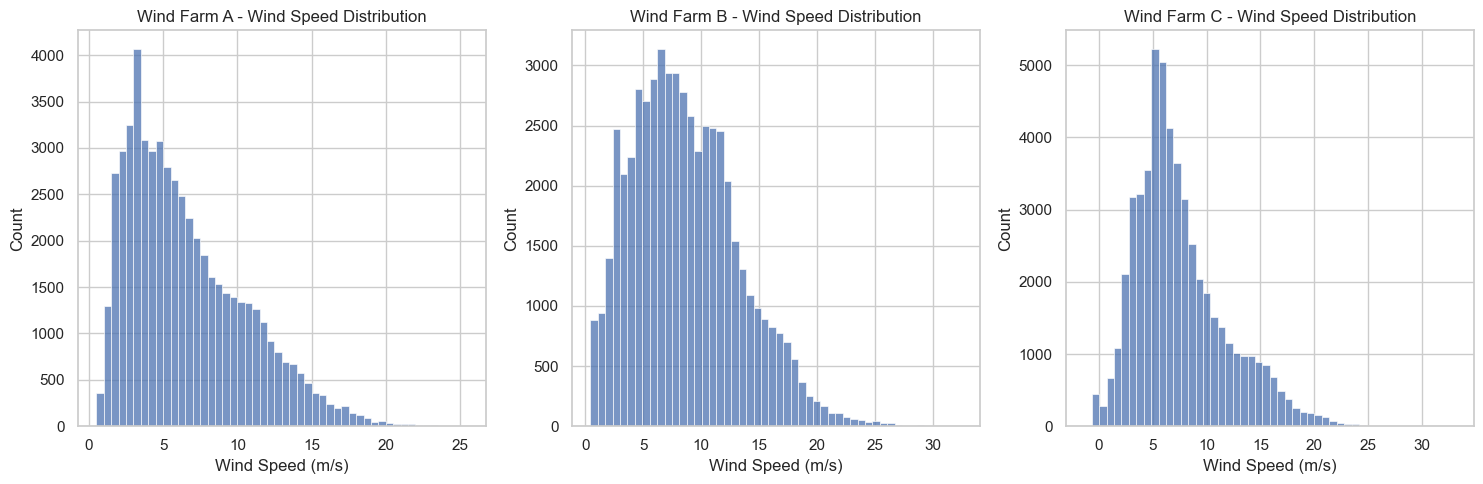


Wind Speed Statistics by Farm:

Wind Farm A:
count    54986.000000
mean         6.532088
std          3.985269
min          0.500000
25%          3.300000
50%          5.600000
75%          9.000000
max         25.500000
Name: wind_speed_3_avg, dtype: float64

Wind Farm B:
count    54774.000000
mean         8.653639
std          4.620891
min          0.440000
25%          5.120000
50%          8.110000
75%         11.580000
max         32.430000
Name: wind_speed_59_avg, dtype: float64

Wind Farm C:
count    53569.000000
mean         7.503012
std          4.228168
min         -1.368000
25%          4.644000
50%          6.538000
75%          9.625000
max         33.118000
Name: wind_speed_236_avg, dtype: float64


In [20]:
# Compare wind speed distributions across farms
plt.figure(figsize=(15, 5))

for i, (farm, data) in enumerate(farm_data.items(), 1):
    plt.subplot(1, 3, i)
    # Find wind speed column
    wind_speed_col = [col for col in data.columns if 'wind_speed' in col.lower() and 'avg' in col.lower()][0]
    sns.histplot(data[wind_speed_col], bins=50)
    plt.title(f'Wind Farm {farm} - Wind Speed Distribution')
    plt.xlabel('Wind Speed (m/s)')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Compare basic statistics
print("\nWind Speed Statistics by Farm:")
for farm, data in farm_data.items():
    wind_speed_col = [col for col in data.columns if 'wind_speed' in col.lower() and 'avg' in col.lower()][0]
    print(f"\nWind Farm {farm}:")
    print(data[wind_speed_col].describe())

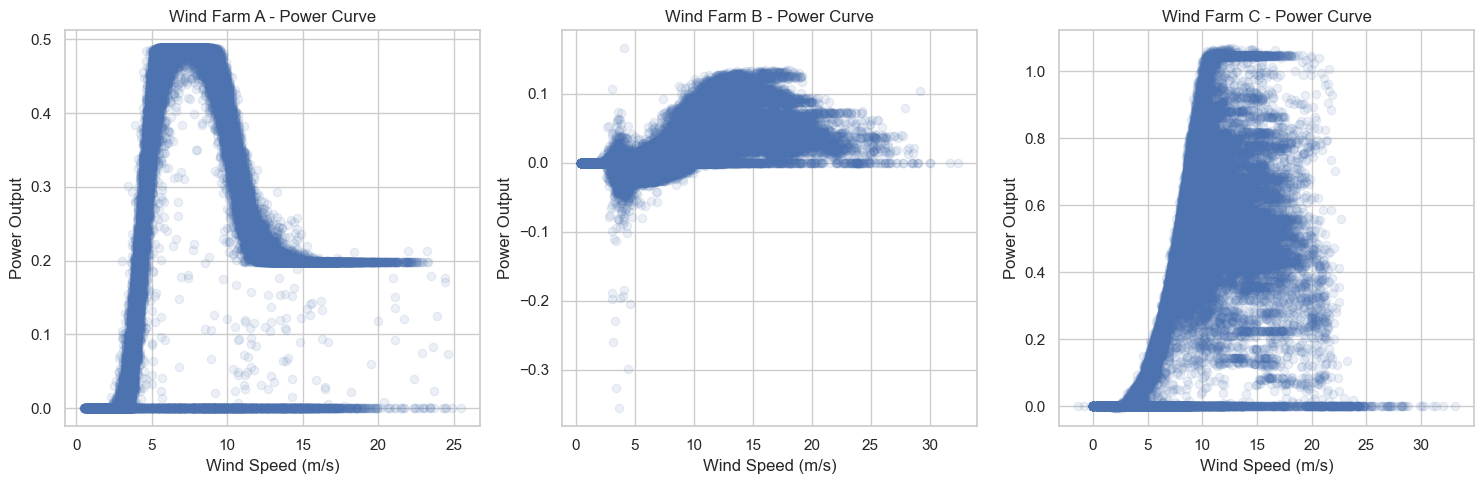


Event Distributions by Farm:

Wind Farm A Event Types:
event_description
Hydraulic group              6
Gearbox failure              2
Generator bearing failure    2
Transformer failure          1
Gearbox bearings damaged     1
Name: count, dtype: int64

Wind Farm B Event Types:
event_description
high temperature in transformer cell                                3
Rotor Bearing 2 - Damage                                            1
Turbine is stopped due to a main bearing damage                     1
Turbine is in standstill since 01.08 due to rotorbearing damage.    1
Name: count, dtype: int64

Wind Farm C Event Types:
event_description
23020 : Axis 3 not ready-to-operate                                                                                                                                                                                                                       2
Harting plug Nacelle/HUB damaged + NCR20_HUB: Wiring blade control system                          

In [21]:
# Compare power curves across farms
plt.figure(figsize=(15, 5))

for i, (farm, data) in enumerate(farm_data.items(), 1):
    plt.subplot(1, 3, i)
    # Find wind speed and power columns
    wind_speed_col = [col for col in data.columns if 'wind_speed' in col.lower() and 'avg' in col.lower()][0]
    power_cols = [col for col in data.columns if 'power' in col.lower() and 'avg' in col.lower()]
    
    if power_cols:
        plt.scatter(data[wind_speed_col], data[power_cols[0]], alpha=0.1)
        plt.title(f'Wind Farm {farm} - Power Curve')
        plt.xlabel('Wind Speed (m/s)')
        plt.ylabel('Power Output')

plt.tight_layout()
plt.show()

# Compare event distributions
print("\nEvent Distributions by Farm:")
for farm in ['A', 'B', 'C']:
    events = load_event_info(farm)
    print(f"\nWind Farm {farm} Event Types:")
    print(events['event_description'].value_counts())

## Comparative Analysis Summary

1. **Feature Set Differences:**
   - Wind Farm A: 86 features (basic sensor set)
   - Wind Farm B: 257 features (expanded sensor set)
   - Wind Farm C: 957 features (comprehensive monitoring)

2. **Wind Speed Characteristics:**
   - Wind Farm A: Mean speed 6.53 m/s, range 0.5-25.5 m/s
   - Wind Farm B: Mean speed 8.65 m/s, range 0.44-32.43 m/s (highest mean)
   - Wind Farm C: Mean speed 7.50 m/s, range -1.37-33.12 m/s (widest range)

3. **Power Curve Characteristics:**
   - All farms show typical wind turbine power curves
   - Cut-in speed around 3-4 m/s
   - Different rated power levels (normalized values)
   - Wind Farm B shows highest wind speeds and most consistent power curve
   - Wind Farm C shows more scattered power output at higher wind speeds

4. **Anomaly Events:**
   - Common failure types across farms: Gearbox, Hydraulic, Generator bearing
   - Each farm has unique failure patterns and frequencies
   - Event durations typically range from 7-14 days

### Key Observations:
1. Wind Farm B appears to be in a location with consistently higher wind speeds
2. Different instrumentation levels suggest varying monitoring capabilities
3. Power curves show similar patterns but with farm-specific characteristics
4. Each farm has unique operational challenges and failure modes

### Recommendations for Analysis:
1. **Feature Selection:**
   - Use common features across all farms for unified models
   - Develop farm-specific models using extended feature sets where available

2. **Preprocessing:**
   - Normalize wind speeds and power outputs for cross-farm comparison
   - Handle missing or erroneous values (e.g., negative wind speeds in Farm C)
   - Consider wind direction and environmental factors

3. **Model Development:**
   - Create separate baseline models for each farm
   - Develop transfer learning approaches to share insights across farms
   - Account for different sensor configurations in model architecture

## Deep Learning Model Recommendations

Based on the analysis of the wind turbine data across all three farms, here are the recommended deep learning approaches:

### 1. LSTM/GRU-based Models
**Reasons for recommendation:**
- Time series nature of the data (10-minute intervals)
- Ability to capture long-term dependencies
- Can handle variable-length sequences
- Suitable for multivariate sensor data

**Specific architectures:**
- Bidirectional LSTM for capturing both past and future context
- Encoder-Decoder LSTM for sequence-to-sequence prediction
- Attention mechanisms to focus on relevant time steps during anomaly events

### 2. Transformer-based Models
**Reasons for recommendation:**
- Excellent at capturing long-range dependencies
- Can process parallel sensor streams effectively
- Self-attention mechanism helps identify relevant patterns
- Good at handling missing data through masking

**Specific architectures:**
- Time Series Transformer
- Temporal Fusion Transformer (TFT)
- Informer for long sequence modeling

### 3. Hybrid CNN-LSTM Models
**Reasons for recommendation:**
- CNNs can extract local patterns from sensor signals
- LSTM layers can model temporal dependencies
- Good for handling multi-scale patterns
- Efficient feature extraction from raw sensor data

### 4. Autoencoder-based Models
**Reasons for recommendation:**
- Unsupervised anomaly detection
- Can handle different feature sets across farms
- Good for dimensionality reduction of high-dimensional sensor data
- Can reconstruct normal behavior patterns

**Specific architectures:**
- Variational Autoencoders (VAEs) for probabilistic modeling
- LSTM Autoencoders for temporal reconstruction
- Hierarchical Autoencoders for multi-scale features

### Model Architecture Considerations

1. **Input Features:**
   - Variable number of features across farms (86 to 957)
   - Mix of sensor types (temperatures, speeds, angles, power)
   - Different sampling rates and patterns

2. **Output Design:**
   - Anomaly score prediction
   - Multi-class classification for different failure types
   - Time-to-failure prediction

3. **Architecture Specifics:**
   ```
   Input Layer (Multivariate Time Series)
   ↓
   Feature Extraction (CNN/Transformer)
   ↓
   Temporal Modeling (LSTM/GRU)
   ↓
   Attention Layer
   ↓
   Dense Layers
   ↓
   Output Layer (Anomaly Detection)
   ```

### Implementation Strategy

1. **Data Preprocessing:**
   - Standardization/Normalization
   - Sliding window approach for sequence creation
   - Missing value imputation
   - Feature alignment across farms

2. **Training Approach:**
   - Start with individual farm models
   - Develop transfer learning between farms
   - Use pre-training on normal operation data
   - Fine-tune on specific failure types

3. **Validation Strategy:**
   - Time-based validation splits
   - Cross-validation across different turbines
   - Separate validation for each failure type

### Model Selection Criteria:
1. **For Farm A (86 features):**
   - Simpler LSTM/GRU architectures
   - Focus on core sensor relationships
   - Lighter model complexity

2. **For Farm B (257 features):**
   - Hybrid CNN-LSTM models
   - More complex feature interactions
   - Medium model complexity

3. **For Farm C (957 features):**
   - Full Transformer architecture
   - Advanced feature selection/reduction
   - Higher model complexity

### Final Recommendation:
Start with a **Hierarchical Transformer-LSTM** model:
1. Transformer layers for feature extraction and attention
2. LSTM layers for temporal modeling
3. Autoencoder branch for unsupervised anomaly detection
4. Transfer learning capabilities between farms

This architecture can:
- Handle variable feature sets
- Capture temporal dependencies
- Scale across different farm configurations
- Provide interpretable attention maps
- Detect both known and unknown anomalies

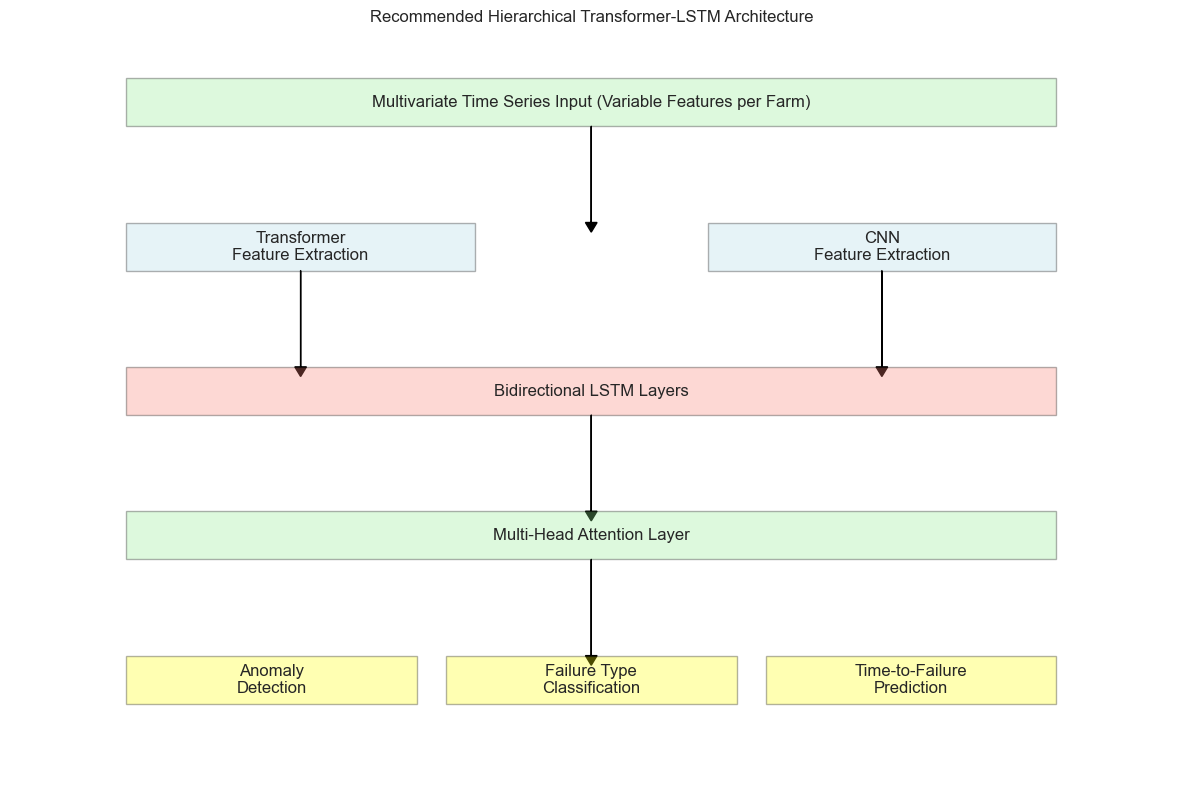

In [22]:
from matplotlib.patches import Rectangle, FancyArrow
import matplotlib.patches as patches

# Create a visual representation of the model architecture
plt.figure(figsize=(15, 10))

# Function to add a box with text
def add_box(ax, x, y, width, height, text, color='lightblue', alpha=0.3):
    rect = Rectangle((x, y), width, height, facecolor=color, alpha=alpha, edgecolor='black')
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center')

# Function to add an arrow
def add_arrow(ax, x1, y1, x2, y2):
    ax.arrow(x1, y1, x2-x1, y2-y1, head_width=0.1, head_length=0.1, fc='black', ec='black')

# Set up the plot
ax = plt.gca()
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# Add model components
add_box(ax, 1, 7, 8, 0.5, 'Multivariate Time Series Input (Variable Features per Farm)', 'lightgreen')
add_arrow(ax, 5, 7, 5, 6)

# Feature processing
add_box(ax, 1, 5.5, 3, 0.5, 'Transformer\nFeature Extraction', 'lightblue')
add_box(ax, 6, 5.5, 3, 0.5, 'CNN\nFeature Extraction', 'lightblue')
add_arrow(ax, 2.5, 5.5, 2.5, 4.5)
add_arrow(ax, 7.5, 5.5, 7.5, 4.5)

# Temporal modeling
add_box(ax, 1, 4, 8, 0.5, 'Bidirectional LSTM Layers', 'salmon')
add_arrow(ax, 5, 4, 5, 3)

# Attention mechanism
add_box(ax, 1, 2.5, 8, 0.5, 'Multi-Head Attention Layer', 'lightgreen')
add_arrow(ax, 5, 2.5, 5, 1.5)

# Output layers
add_box(ax, 1, 1, 2.5, 0.5, 'Anomaly\nDetection', 'yellow')
add_box(ax, 3.75, 1, 2.5, 0.5, 'Failure Type\nClassification', 'yellow')
add_box(ax, 6.5, 1, 2.5, 0.5, 'Time-to-Failure\nPrediction', 'yellow')

plt.title('Recommended Hierarchical Transformer-LSTM Architecture')
plt.show()